In [2]:
import pandas as pd

df = pd.read_csv("telco.csv")

df.head()


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.columns
df.info()


In [ ]:
df.isnull().sum()


In [3]:
df.columns = df.columns.str.replace(" ", "_")
df.isnull().sum()
num_cols = [
    'Monthly_Charge', 'Total_Charges', 'Total_Revenue',
    'Tenure_in_Months', 'Avg_Monthly_GB_Download'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [4]:
df.dropna(inplace=True)


In [16]:
import sqlite3

conn = sqlite3.connect("churn.db")
df.to_sql("customers", conn, if_exists="replace", index=False)


757

In [19]:
query = """
SELECT Churn_Label, COUNT(*) AS total_customers
FROM customers
GROUP BY Churn_Label
"""

pd.read_sql(query, conn)


,Churn_Label,total_customers
0,Yes,757


In [21]:
query1 = """
SELECT Churn_Label, COUNT(*) AS total
FROM customers
GROUP BY Churn_Label
"""
pd.read_sql(query1, conn)


,Churn_Label,total
0,Yes,757


In [22]:
query2 = """
SELECT Churn_Label, AVG(Monthly_Charge) AS avg_charge
FROM customers
GROUP BY Churn_Label
"""
pd.read_sql(query2, conn)


,Churn_Label,avg_charge
0,Yes,77.548018


In [24]:
query3 = """
SELECT Contract, Churn_Label, COUNT(*) AS total
FROM customers
GROUP BY Contract, Churn_Label
"""
pd.read_sql(query3, conn)


,Contract,Churn_Label,total
0,Month-to-Month,Yes,667
1,One Year,Yes,70
2,Two Year,Yes,20


In [26]:
query4 = """
SELECT Churn_Reason, COUNT(*) AS total
FROM customers
WHERE Churn_Label = 'Yes'
GROUP BY Churn_Reason
ORDER BY total DESC
LIMIT 5
"""
pd.read_sql(query4, conn)


,Churn_Reason,total
0,Competitor had better devices,133
1,Competitor made better offer,126
2,Attitude of support person,84
3,Competitor offered more data,58
4,Attitude of service provider,49


Key Insights:

Month-to-month contract customers have the highest churn

Customers with higher monthly charges are more likely to churn

Short tenure customers churn more than long-term customers

Service-related issues are a major churn reason

In [5]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\kashi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


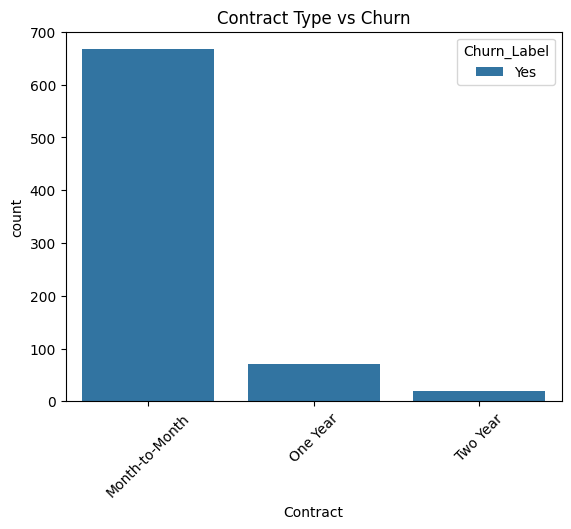

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Contract', hue='Churn_Label', data=df)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()


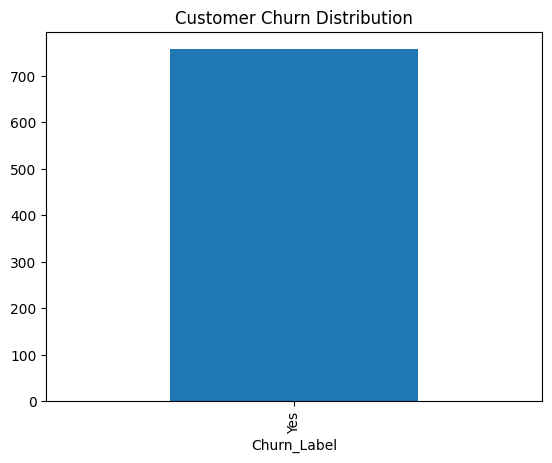

In [32]:
import matplotlib.pyplot as plt

df['Churn_Label'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.show()


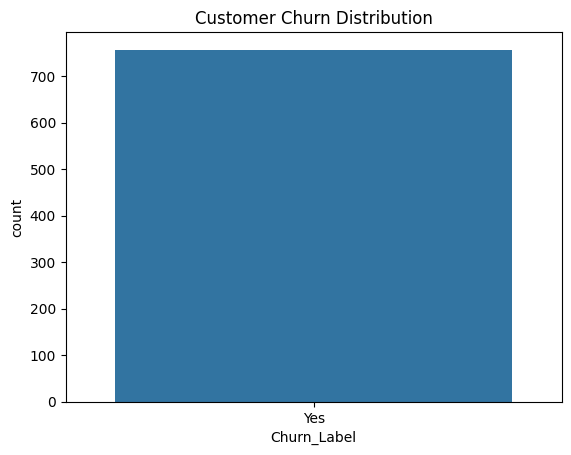

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn_Label', data=df)
plt.title("Customer Churn Distribution")
plt.show()


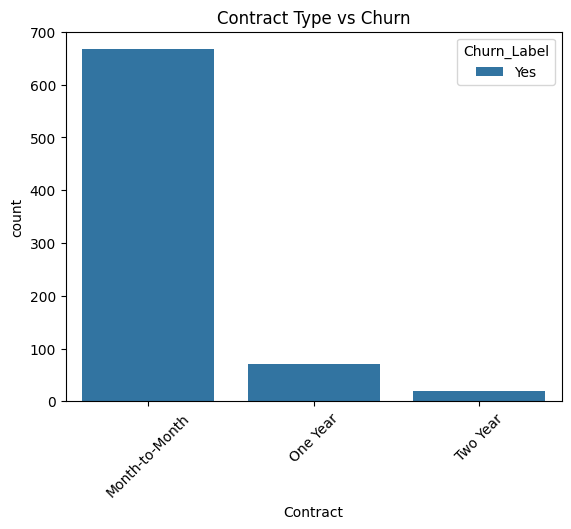

In [34]:
sns.countplot(x='Contract', hue='Churn_Label', data=df)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()


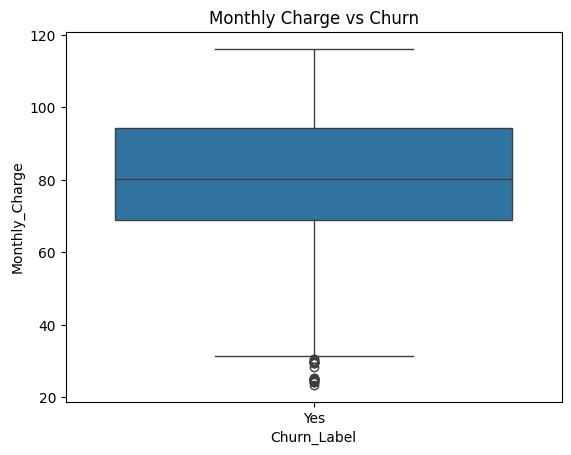

In [36]:
sns.boxplot(x='Churn_Label', y='Monthly_Charge', data=df)
plt.title("Monthly Charge vs Churn")
plt.show()


Key Insights

Month-to-month contract customers show the highest churn

Customers with higher monthly charges are more likely to churn

Long-tenure customers are less likely to churn

Contract type and pricing significantly impact churn behavior